In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
import hyperopt
import matplotlib as mpl
import sys
sys.path.append('../spock/')
try:
    plt.style.use('paper')
except:
    pass
%matplotlib inline

Load the models

In [35]:
# #load datapath for clean training data that is generated
datapath = '../training_data/dataset/resonant/'

data = pd.read_csv(datapath + '12-4-25-REAL.csv')
# data = pd.read_csv(datapath + '11-20-25data.csv')
# data = pd.read_csv(datapath + '7-30-25-FINALx2.csv')
# data = pd.read_csv(datapath + '5-19-25-massOrder.csv')
# data = pd.read_csv(datapath + '5-22-25-3BRfill.csv')


# #remove junk columns
data = data.drop(columns=['Unnamed: 0','Unnamed: 0.1'])

In [36]:
data.count()

EMcrossMax                  102497
EMfracstdMax                 95951
EPstdMax                     95951
MMRstrengthMax               93551
conjunctionMagMax           102497
relConjunctionMagMax        102497
pomega1ThetaMax             102497
pomega2ThetaMax             102497
pMax                        102497
qMax                        102497
dRatioMax                    95951
hillFacMax                   95951
EMcrossMin                  102497
EMfracstdMin                 95951
EPstdMin                     95951
MMRstrengthMin               78590
conjunctionMagMin           102497
relConjunctionMagMin        102497
pomega1ThetaMin             102497
pomega2ThetaMin             102497
pMin                        102497
qMin                        102497
dRatioMin                    95951
hillFacMin                   95951
MEGNO                        95951
MEGNOstd                     95951
massOrder                   102497
threeBRfillfac               95951
massFac             

In [37]:
data.columns

Index(['EMcrossMax', 'EMfracstdMax', 'EPstdMax', 'MMRstrengthMax',
       'conjunctionMagMax', 'relConjunctionMagMax', 'pomega1ThetaMax',
       'pomega2ThetaMax', 'pMax', 'qMax', 'dRatioMax', 'hillFacMax',
       'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'pomega1ThetaMin',
       'pomega2ThetaMin', 'pMin', 'qMin', 'dRatioMin', 'hillFacMin', 'MEGNO',
       'MEGNOstd', 'massOrder', 'threeBRfillfac', 'massFac',
       'mass_fac_lowest_std', 'mass_fac_lowest_norm_std', 'min_e_std',
       'min_norm_e_std', 'massFacLargeMass', 'Tsec', '2BRfillMax',
       '2BRfillMin', 'conjunctionMagCutoff', 'relConjunctionMagCutoff',
       'InitialStable', 'shortIntegrationStable', 'runstring',
       'instability_time', 'shadow_instability_time', 'Stable'],
      dtype='object')

add column taking the max of the two diff conjunction angle methods to see if we can reduce feature dimension without decreasing performance, currently the two methods are not consistent so you can not.... this seems like something that would be good to resolve

In [5]:
data['magMax'] = np.max([data['conjunctionMagMax'], data['relConjunctionMagMax']])
data['magMin'] = np.max([data['conjunctionMagMin'], data['relConjunctionMagMin']])

Make feature list to test [feature] importance

In [6]:
featuresNew = ['EMcrossMax', 'EMfracstdMax', 'EPstdMax',
       'MMRstrengthMax', 'conjunctionMagMax', 'relConjunctionMagMax',
       'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd',
       'massOrder',  'Tsec', '2BRfillMax', '2BRfillMin', 'dRatioMax', 'dRatioMin', 
       'hillFacMax', 'hillFacMin', 'massFac', 'mass_fac_lowest_std', 'mass_fac_lowest_norm_std', 
       'massFacLargeMass', 'shortIntegrationStable', 'min_norm_e_std', 'min_e_std', 'threeBRfillfac']
featuresWidth = ['EMcrossMax', 'EMfracstdMax', 'EPstdMax', 'conjunctionMagMax', 
       'relConjunctionMagMax', 'EMcrossMin', 'EMfracstdMin', 'EPstdMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd',
       'massOrder',  'Tsec', '2BRfillMax', '2BRfillMin', 'dRatioMax', 'dRatioMin']
features = ['EMcrossMax', 'EMfracstdMax', 'EPstdMax',
       'MMRstrengthMax', 'conjunctionMagMax', 'relConjunctionMagMax',
       'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd',
       'massOrder',  'Tsec', '2BRfillMax', '2BRfillMin']

In [7]:
def train_test(dataset,features):
    '''divides the dataset into 80% training and 20% testing and returns training/testing sets'''
    Nrows = int(0.8*dataset.shape[0])
    train = dataset.iloc[:Nrows, :]
    test = dataset.iloc[Nrows:, :]
    #remove testing systems that go unstable in 1e4 orbits

    test = test.drop(test[test['InitialStable']==False].index)
    return train[features], train['Stable'], test[features], test['Stable']

In [8]:

trainX, trainY, testX, testY = train_test(data, featuresNew)

In [9]:
print(featuresNew)

['EMcrossMax', 'EMfracstdMax', 'EPstdMax', 'MMRstrengthMax', 'conjunctionMagMax', 'relConjunctionMagMax', 'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin', 'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd', 'massOrder', 'Tsec', '2BRfillMax', '2BRfillMin', 'dRatioMax', 'dRatioMin', 'hillFacMax', 'hillFacMin', 'massFac', 'mass_fac_lowest_std', 'mass_fac_lowest_norm_std', 'massFacLargeMass', 'shortIntegrationStable', 'min_norm_e_std', 'min_e_std', 'threeBRfillfac']


In [10]:
from sklearn import metrics
from sklearn.metrics import roc_curve, confusion_matrix, auc
def ROC_curve( model, x,y):
    preds = model.predict_proba(x)[:,1]
    fpr, tpr, ROCthresholds = roc_curve(y, preds)
    roc_auc = metrics.roc_auc_score(y, preds)
    return roc_auc, fpr, tpr, ROCthresholds

In [11]:
model = XGBClassifier(learning_rate = 0.05, 
                         max_depth = 15, 
                         subsample = 0.95,
                         min_child_weight = 5,
                         n_estimators = 200,
                         )

In [12]:
model.fit(trainX,trainY)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=15, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

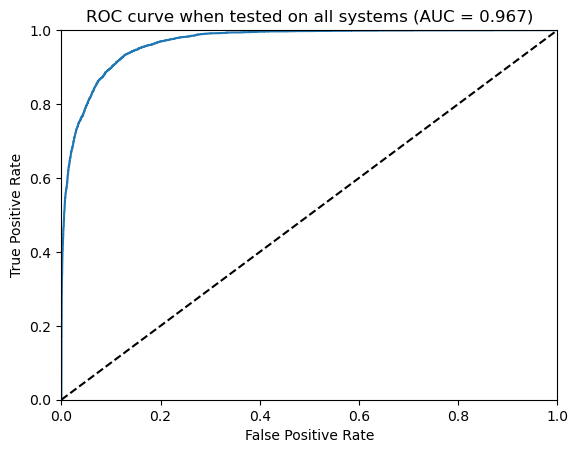

In [13]:
roc_auc, fpr, tpr, ROCthresholds = ROC_curve(model, testX, testY)

fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve when tested on all systems (AUC = {0:.3f})'.format(roc_auc))
plt.show()


In [14]:
roc_auc

0.9669197341692292

Identify inconstant systems where the two conjunction angle calculations don't match
Our current understanding indicates sometimes the rel calculation wont detect a resonance, but the not rel calc should always find one IF the rel one finds a resonance, this is not the case however....

Make graphs to determine which value is the cut off for which population is resonant or not and for where the massFac has its critical value.

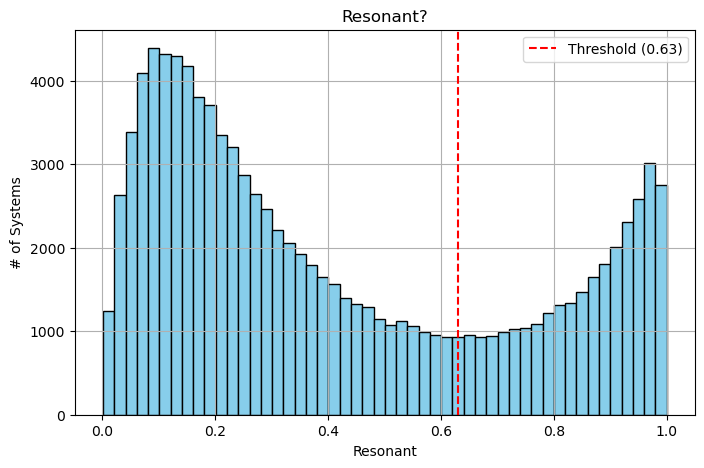

In [38]:
counts, bin_edges = np.histogram(data['conjunctionMagCutoff'], bins=50)

# Find the bin with the minimum count
min_idx = np.argmin(counts)
threshold = (bin_edges[min_idx] + bin_edges[min_idx + 1]) / 2  # middle of that bin

plt.figure(figsize=(8, 5))
plt.hist(data['conjunctionMagCutoff'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.2f})')
plt.xlabel('Resonant')
plt.ylabel('# of Systems')
plt.title('Resonant?')
plt.legend()
plt.grid(True)
plt.show()

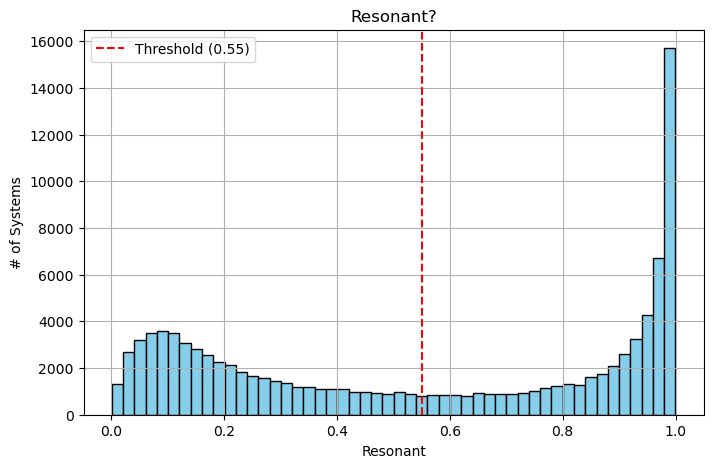

In [39]:
counts, bin_edges = np.histogram(data['relConjunctionMagCutoff'], bins=50)

# Find the bin with the minimum count
min_idx = np.argmin(counts)
threshold = (bin_edges[min_idx] + bin_edges[min_idx + 1]) / 2  # middle of that bin

plt.figure(figsize=(8, 5))
plt.hist(data['relConjunctionMagCutoff'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.2f})')
plt.xlabel('Resonant')
plt.ylabel('# of Systems')
plt.title('Resonant?')
plt.legend()
plt.grid(True)
plt.show()


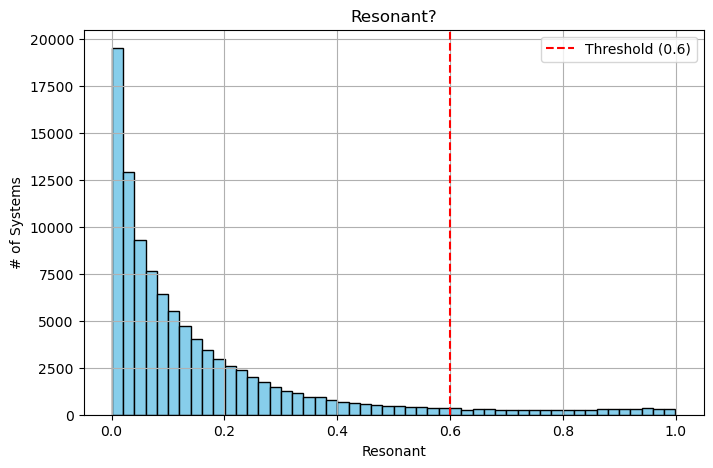

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(data['conjunctionMagMin'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(0.6, color='red', linestyle='--', label='Threshold (0.6)')
plt.xlabel('Resonant')
plt.ylabel('# of Systems')
plt.title('Resonant?')
plt.legend()
plt.grid(True)
plt.show()

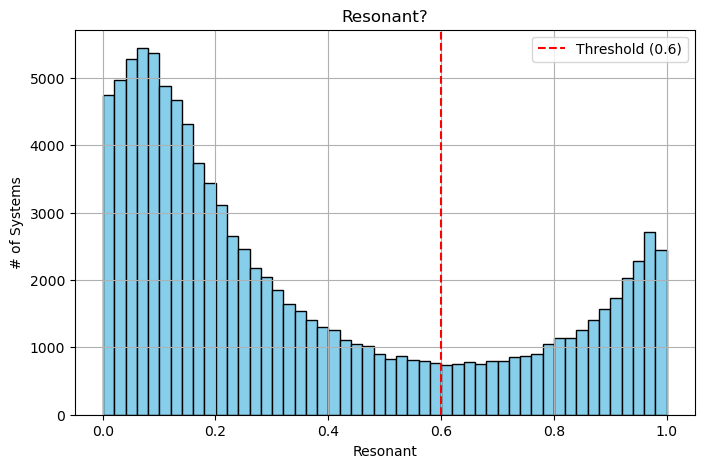

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(data['conjunctionMagMax'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(0.6, color='red', linestyle='--', label='Threshold (0.6)')
plt.xlabel('Resonant')
plt.ylabel('# of Systems')
plt.title('Resonant?')
plt.legend()
plt.grid(True)
plt.show()

look for non res on right,
look for res on left 

So, the cut off for resonant values would be 0.6. 

In [16]:
nonres = ((data['conjunctionMagMax'] < 0.6 ) & (data['relConjunctionMagMax'] < 0.6))

Make a graph to determine the cut off for massFac for a 2-body system

634


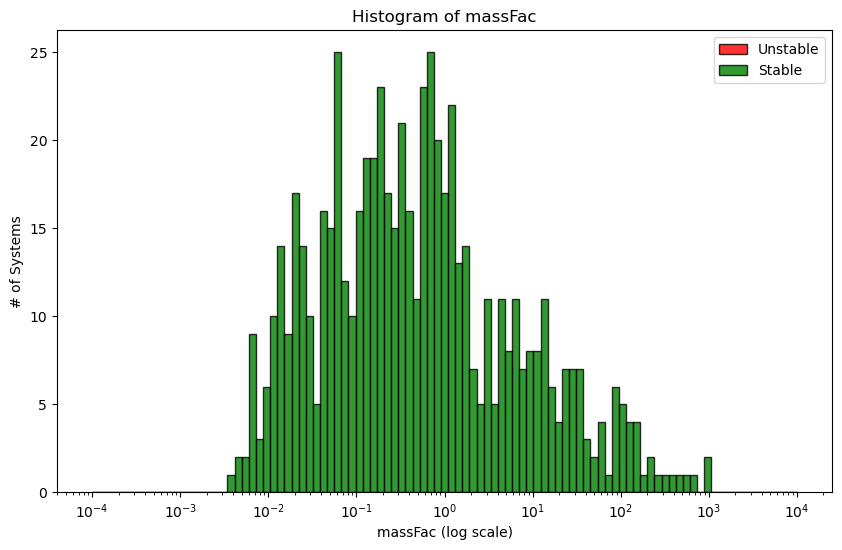

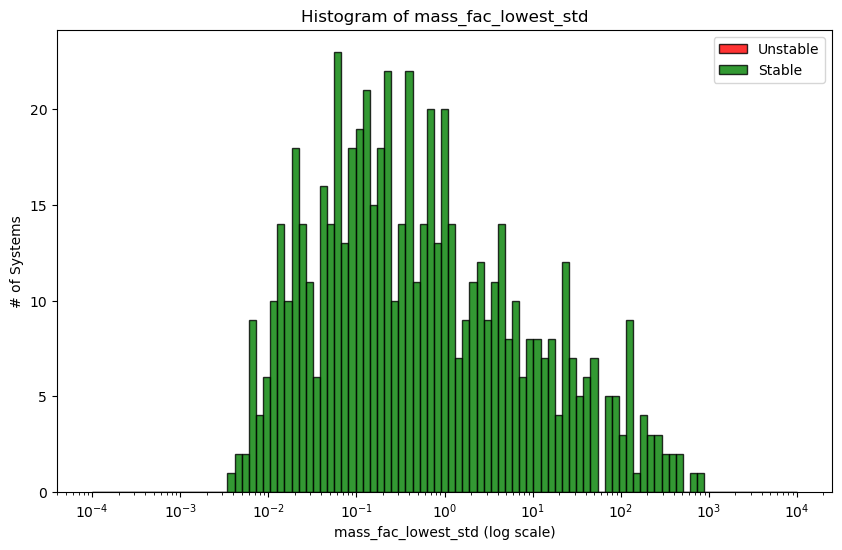

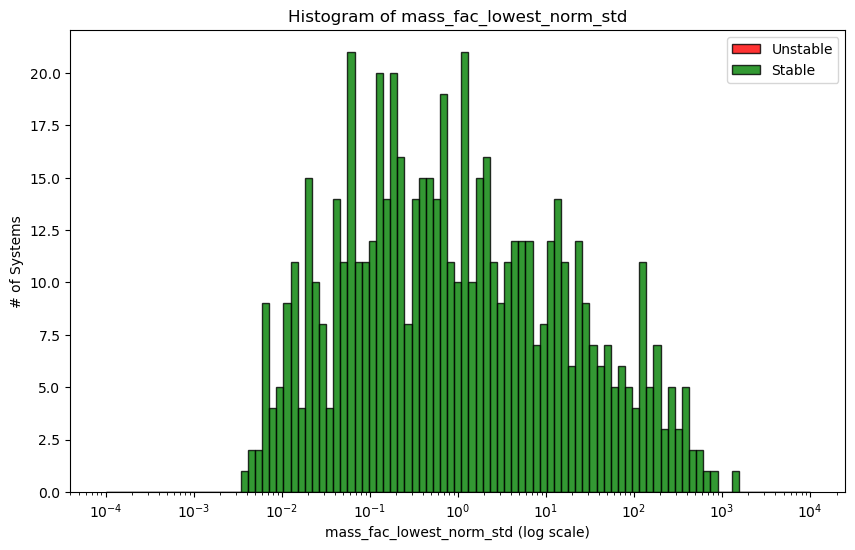

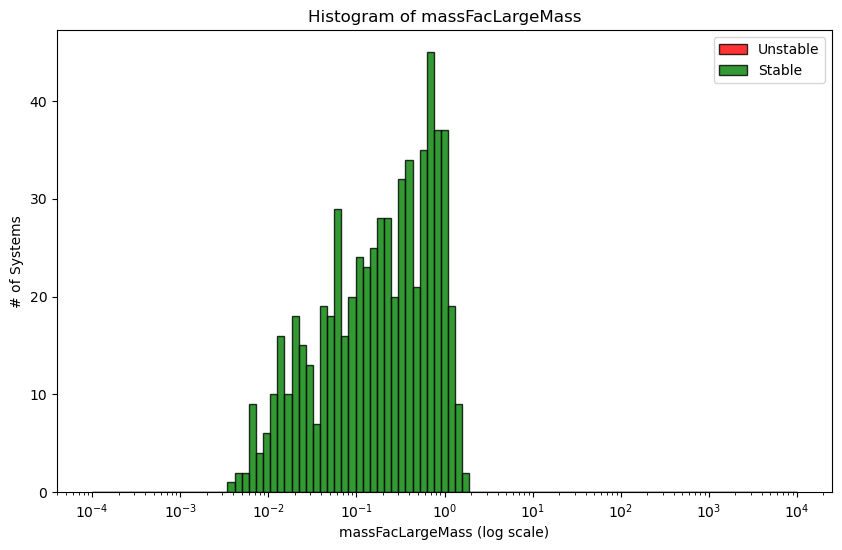

In [17]:
stable = data[data['shortIntegrationStable'] == True]

nonres = stable[
    (stable['conjunctionMagMax'] < 0.6) & 
    (stable['relConjunctionMagMax'] < 0.6)
]

nonres_MMRoverlap = nonres[nonres['2BRfillMax'] > 1]

# if we want to consider the hillFacMax, we can use the line below:
# filtered = nonres_MMRoverlap[nonres_MMRoverlap['hillFacMax'] > 1]

# isolate the exceptions that are stable that we think should be unstable 
exceptions = nonres_MMRoverlap[nonres_MMRoverlap['Stable'] == True]
check_pred_unstable = nonres_MMRoverlap[nonres_MMRoverlap['Stable'] == False]

print(len(exceptions))
filtered = exceptions.copy()


mass_fac_cols = ['massFac', 'mass_fac_lowest_std', 'mass_fac_lowest_norm_std', 'massFacLargeMass']
bins = np.logspace(-4, 4, 100)  # from 1e-4 to 1e4

# bins = np.linspace(0, 20, 100)

for col in mass_fac_cols:
    stable_vals = filtered[filtered['Stable'] == True][col]
    unstable_vals = filtered[filtered['Stable'] == False][col]

    plt.figure(figsize=(10, 6))
    plt.hist([unstable_vals, stable_vals], bins=bins, stacked=True,
             color=['red', 'green'], label=['Unstable', 'Stable'],
             edgecolor='black', alpha=0.8)
    

    plt.xscale('log')
    plt.xlabel(f'{col} (log scale)')
    plt.ylabel('# of Systems')
    plt.title(f'Histogram of {col}')
    plt.legend()
    plt.show()



634


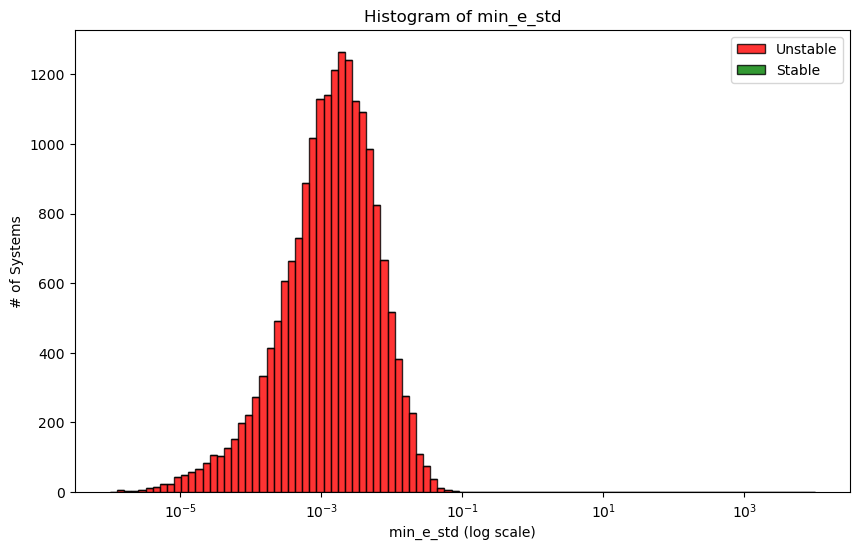

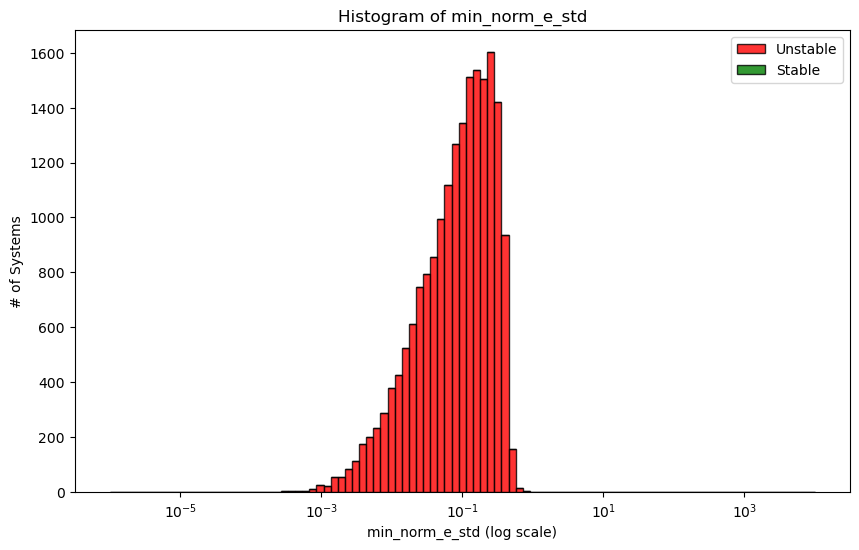

In [18]:
stable = data[data['shortIntegrationStable'] == True]

nonres = stable[
    (stable['conjunctionMagMax'] < 0.6) & 
    (stable['relConjunctionMagMax'] < 0.6)
]

nonres_MMRoverlap = nonres[nonres['2BRfillMax'] > 1]

# if we want to consider the hillFacMax, we can use the line below:
# filtered = nonres_MMRoverlap[nonres_MMRoverlap['hillFacMax'] > 1]

# isolate the exceptions that are stable that we think should be unstable 
exceptions = nonres_MMRoverlap[nonres_MMRoverlap['Stable'] == True]
check_pred_unstable = nonres_MMRoverlap[nonres_MMRoverlap['Stable'] == False]

print(len(exceptions))
filtered = check_pred_unstable.copy()


ecc_std_cols = ['min_e_std', 'min_norm_e_std']
bins = np.logspace(-6, 4, 100)

for col in ecc_std_cols:
    stable_vals = filtered[filtered['Stable'] == True][col]
    unstable_vals = filtered[filtered['Stable'] == False][col]

    plt.figure(figsize=(10, 6))
    plt.hist([unstable_vals, stable_vals], bins=bins, stacked=True,
             color=['red', 'green'], label=['Unstable', 'Stable'],
             edgecolor='black', alpha=0.8)
    

    plt.xscale('log')
    plt.xlabel(f'{col} (log scale)')
    plt.ylabel('# of Systems')
    plt.title(f'Histogram of {col}')
    plt.legend()
    plt.show()

In [19]:
check_pred_unstable.to_csv(datapath+'7-11-25-97percent.csv')

 'massFac', 'mass_fac_lowest_std', 'mass_fac_lowest_norm_std', 'massFacLargeMass',

In [22]:
# Loop over log-binned thresholds
thresholds = np.logspace(-4, 4, 100)
results = []

for cut in thresholds:
    subset = filtered[filtered['massFac'] < cut]
    total = len(subset)
    if total == 0:
        continue
    unstable = (subset['Stable'] == False).sum()
    results.append({
        'massFac_cut': cut,
        'total': total,
        'unstable': unstable,
        'all_stable': unstable == 0
    })

# Find largest cut where all systems below it are stable
df = pd.DataFrame(results)
valid = df[df['all_stable']]
best = valid.sort_values(by='massFac_cut', ascending=False).iloc[0]

print(results)


IndexError: single positional indexer is out-of-bounds

In [66]:
22584/23151

0.9755086173383439

**INFO for Stability Tree

In [40]:
unstable = (data[data['shortIntegrationStable'] == False])
len(unstable)

6546

In [13]:
unstable['Stable'].describe()
# 6535/6546

count      6546
unique        2
top       False
freq       6535
Name: Stable, dtype: object

In [47]:
stable = data[data['shortIntegrationStable'] == True]
print(f"stable count: {len(stable)}")

# nonres = stable[
#     (stable['conjunctionMagMax'] < 0.6) & 
#     (stable['relConjunctionMagMax'] < 0.6) #prev 0.8 (elio) or 0.6 (mine)
# ]

# res = stable[
#     (stable['conjunctionMagMax'] > 0.6) | 
#     (stable['relConjunctionMagMax'] > 0.6)
# ]


nonres = stable[
    (stable['conjunctionMagCutoff'] < 0.63) & 
    (stable['relConjunctionMagCutoff'] < 0.55) #prev 0.8 (elio) or 0.6 (mine)
]

res = stable[
    (stable['conjunctionMagCutoff'] > 0.63) | 
    (stable['relConjunctionMagCutoff'] > 0.55)
]


print(f"nonres count: {len(nonres)}")
print(f"res count: {len(res)}")
print(f"nonres + res total: {len(nonres) + len(res)}")

stable count: 95951
nonres count: 43646
res count: 52305
nonres + res total: 95951


In [49]:
res_stable = (res[res['Stable'] == False])
print(len(res_stable))

33344


In [50]:
nonres_MMRoverlap = nonres[nonres['2BRfillMax'] > 1]
nonres_no_MMRoverlap = nonres[nonres['2BRfillMax'] < 1]
nonres_null_MMRoverlap = nonres[nonres['2BRfillMax'].isnull()]

print(f"nonres systems: {len(nonres)}")
print(f"nonres systems with 2BRfillMax < 1: {len(nonres_no_MMRoverlap)}")
print(f"nonres systems with 2BRfillMax > 1: {len(nonres_MMRoverlap)}")
print(f"nonres systems with 2BRfillMax is NaN: {len(nonres_null_MMRoverlap)}")
print(f"overlap + no overlap total: {len(nonres_no_MMRoverlap) + len(nonres_MMRoverlap) +len(nonres_null_MMRoverlap)}")

nonres systems: 43646
nonres systems with 2BRfillMax < 1: 26679
nonres systems with 2BRfillMax > 1: 16967
nonres systems with 2BRfillMax is NaN: 0
overlap + no overlap total: 43646


In [52]:
hillFacUnstable = nonres_MMRoverlap[nonres_MMRoverlap['hillFacMax'] < 1]
hillFacStable = nonres_MMRoverlap[nonres_MMRoverlap['hillFacMax'] > 1]

print(f"nonres systems with 2BRfillMax > 1 and hillFac < 1: {len(hillFacUnstable)}")
print(f"nonres systems with 2BRfillMax > 1 and hillFac > 1: {len(hillFacStable)}")

nonres systems with 2BRfillMax > 1 and hillFac < 1: 3039
nonres systems with 2BRfillMax > 1 and hillFac > 1: 13928


In [53]:
stable_nonres_MMRoverlap = nonres_MMRoverlap[nonres_MMRoverlap['Stable'] == True]
unstable_nonres_MMRoverlap = nonres_MMRoverlap[nonres_MMRoverlap['Stable'] == False]
hillFacGreater1 = stable_nonres_MMRoverlap[stable_nonres_MMRoverlap['hillFacMax'] > 1]

print(len(unstable_nonres_MMRoverlap))
print(f"Stable nonres system with 2BRfillMax > 1: {len(stable_nonres_MMRoverlap)}")
print(f"Stable nonres systems with 2BRfillMax > 1 and hillFac > 1: {len(hillFacGreater1)}")    

16577
Stable nonres system with 2BRfillMax > 1: 390
Stable nonres systems with 2BRfillMax > 1 and hillFac > 1: 304


In [51]:
nonres_MMRoverlap['Stable'].describe()

count     16967
unique        2
top       False
freq      16577
Name: Stable, dtype: object

In [20]:
23780/26054

0.9127197359330621

In [33]:
unstable_nonres_MMRoverlap.index

Index([     7,     14,     38,     41,     43,     71,     92,     99,    101,
          103,
       ...
       102464, 102467, 102468, 102474, 102477, 102478, 102479, 102482, 102487,
       102488],
      dtype='int64', length=18348)

In [30]:
stable_nonres_MMRoverlap.index

Index([    72,    504,    625,    838,    988,   1156,   1286,   1555,   2163,
         2592,
       ...
       100786, 100807, 101064, 101076, 101101, 101305, 101487, 101605, 102026,
       102048],
      dtype='int64', length=455)

In [31]:
stable_nonres_MMRoverlap.shape

(455, 43)

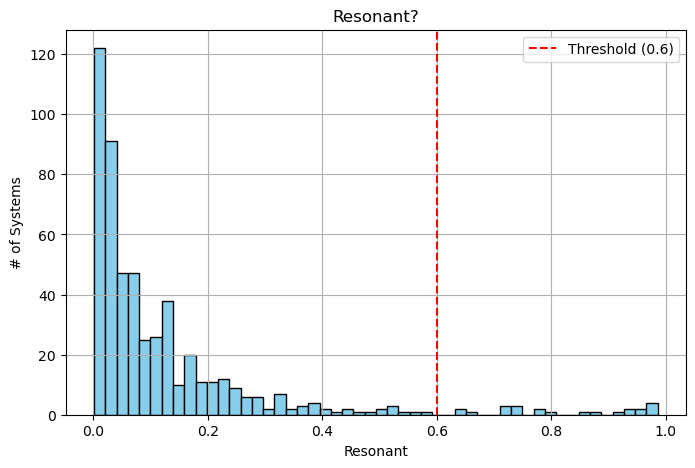

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(stable_nonres_MMRoverlap['conjunctionMagMin'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(0.6, color='red', linestyle='--', label='Threshold (0.6)')
plt.xlabel('Resonant')
plt.ylabel('# of Systems')
plt.title('Resonant?')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
data.loc[69334]

EMcrossMax                      0.037614
EMfracstdMax                    0.407712
EPstdMax                        0.001787
MMRstrengthMax                  0.068336
conjunctionMagMax               0.155284
relConjunctionMagMax            0.076293
pomega1ThetaMax                 0.155284
pomega2ThetaMax                 0.054159
pMax                                37.0
qMax                                 2.0
dRatioMax                       0.103126
hillFacMax                      1.557341
EMcrossMin                      0.128733
EMfracstdMin                    0.014435
EPstdMin                        0.001021
MMRstrengthMin                  0.096672
conjunctionMagMin               0.192628
relConjunctionMagMin            0.192514
pomega1ThetaMin                 0.192628
pomega2ThetaMin                 0.167002
pMin                                 6.0
qMin                                 1.0
dRatioMin                       0.769493
hillFacMin                       2.81851
MEGNO           

***Distribution plots

In [13]:
stable_nonres_MMRoverlap.columns

Index(['EMcrossMax', 'EMfracstdMax', 'EPstdMax', 'MMRstrengthMax',
       'conjunctionMagMax', 'relConjunctionMagMax', 'pomega1ThetaMax',
       'pomega2ThetaMax', 'pMax', 'qMax', 'dRatioMax', 'hillFacMax',
       'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'pomega1ThetaMin',
       'pomega2ThetaMin', 'pMin', 'qMin', 'dRatioMin', 'hillFacMin', 'MEGNO',
       'MEGNOstd', 'massOrder', 'threeBRfillfac', 'massFac',
       'mass_fac_lowest_std', 'mass_fac_lowest_norm_std', 'min_e_std',
       'min_norm_e_std', 'massFacLargeMass', 'Tsec', '2BRfillMax',
       '2BRfillMin', 'InitialStable', 'shortIntegrationStable', 'runstring',
       'instability_time', 'shadow_instability_time', 'Stable'],
      dtype='object')

In [14]:
#features for distribution plots 
features = ['EMcrossMax', 'EMfracstdMax', 'EPstdMax', 'MMRstrengthMax',
       'conjunctionMagMax', 'relConjunctionMagMax', 'pomega1ThetaMax',
       'pomega2ThetaMax', 'pMax', 'qMax', 'dRatioMax', 'hillFacMax',
       'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'pomega1ThetaMin',
       'pomega2ThetaMin', 'pMin', 'qMin', 'dRatioMin', 'hillFacMin', 'MEGNO',
       'MEGNOstd', 'threeBRfillfac',  'mass_fac_lowest_norm_std', 'min_e_std',
       'min_norm_e_std', 'Tsec', '2BRfillMax',
       '2BRfillMin', 'InitialStable', 'shortIntegrationStable', 'runstring',
       'instability_time', 'shadow_instability_time', 'Stable', 'magMax',
       'magMin']

In [32]:
# #PLOTS ALL FEATURES DISTRIBUTION GRAPHS
# # Keep only features present in both datasets
# features = [f for f in features if f in stable_nonres_MMRoverlap.columns and f in unstable_nonres_MMRoverlap.columns]

# for feat in features:
#     stable_data = stable_nonres_MMRoverlap[feat].dropna()
#     unstable_data = unstable_nonres_MMRoverlap[feat].dropna()

#     # Skip features with no data
#     if len(stable_data) == 0 or len(unstable_data) == 0:
#         continue

#     # Skip non-numeric features
#     if not np.issubdtype(stable_data.dtype, np.number) or not np.issubdtype(unstable_data.dtype, np.number):
#         print(f"Skipping non-numeric feature: {feat}")
#         continue

#     # --- Stable systems ---
#     plt.figure(figsize=(7, 4))
#     bins_stable = np.linspace(np.nanmin(stable_data), np.nanmax(stable_data), 30)
#     plt.hist(stable_data, bins=bins_stable, alpha=0.7, color='green', edgecolor='black')
#     plt.title(f"Distribution of {feat} (Stable systems)")
#     plt.xlabel(feat)
#     plt.ylabel("Number of systems")
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#     # --- Unstable systems ---
#     plt.figure(figsize=(7, 4))
#     bins_unstable = np.linspace(np.nanmin(stable_data), np.nanmax(stable_data), 30)
#     plt.hist(unstable_data, bins=bins_unstable, alpha=0.7, color='red', edgecolor='black')
#     plt.title(f"Distribution of {feat} (Unstable systems)")
#     plt.xlabel(feat)
#     plt.ylabel("Number of systems")
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()


In [15]:
nonres_MMRoverlap['Stable'].describe()
# 19027/19661

count     18803
unique        2
top       False
freq      18348
Name: Stable, dtype: object

In [54]:
nonres = (data['conjunctionMagCutoff'] < 0.63) & (data['relConjunctionMagCutoff'] < 0.55)
stable = data['2BRfillMax'] < 1

threeb = nonres & stable

# three-body resonance overlap
threebodyoverlap = data['threeBRfillfac'] > 1
threebody_isnull = data['threeBRfillfac'].isnull()

# print(f"threebody is null: {len(threebody_isnull)}")
threeb_overlap = threeb & threebodyoverlap
num_systems = threeb_overlap.sum()

print(f"Number of non-resonant, [2BRfillMax'] < 1 systems with threeBRfillfac > 1: {num_systems}")


Number of non-resonant, [2BRfillMax'] < 1 systems with threeBRfillfac > 1: 4936


In [55]:
data[threeb_overlap]['Stable'].describe()


count      4936
unique        2
top       False
freq       4866
Name: Stable, dtype: object

In [26]:
nonres = (data['conjunctionMagMax'] < 0.6) & (data['relConjunctionMagMax'] < 0.6)
stable = data['2BRfillMax'] < 1

stable2 = data['Stable'] == False
threeb = nonres & stable

# three-body resonance thet DOESN'T overlap
threebodyoverlap = data['threeBRfillfac'] < 1

threeb_overlap = threeb & threebodyoverlap & stable2
num_systems = threeb_overlap.sum()

print(f"number STABLE: {num_systems}")


number STABLE: 21893


In [23]:
hmm = data['threeBRfillfac'].isnull().sum()
hmm

6546

In [146]:
# weird 9000 nul values for 2BRfillFac
isnulled = (nonres & isnull & stable2)
data[isnulled]

,EMcrossMax,EMfracstdMax,EPstdMax,MMRstrengthMax,conjunctionMagMax,relConjunctionMagMax,pomega1ThetaMax,pomega2ThetaMax,pMax,qMax,...,threeBRfillfac,massFac,Tsec,2BRfillMax,2BRfillMin,InitialStable,runstring,instability_time,shadow_instability_time,Stable
58,0.583629,0.017618,0.005686,0.462866,0.261319,0.246710,0.261319,0.227027,2.0,1.0,...,0.050668,0.193179,6746.564040,NaN,0.095908,1.0,0000058.bin,2.487865e+05,3.312804e+05,False
59,0.683494,0.062319,0.036501,NaN,0.080862,0.084821,0.080862,0.028940,7.0,4.0,...,0.045010,0.972471,19043.696827,NaN,NaN,1.0,0000059.bin,3.731288e+04,9.366938e+04,False
61,0.612972,0.003240,0.001479,0.038682,0.023762,0.029533,0.019097,0.023762,2.0,1.0,...,0.304915,0.466644,4666.796038,NaN,0.794640,1.0,0000061.bin,2.161118e+04,2.752602e+05,False
94,0.587331,NaN,NaN,NaN,0.187772,0.149475,0.053657,0.187772,2.0,1.0,...,NaN,NaN,65822.795299,NaN,0.301887,0.0,0000094.bin,3.373491e+04,2.663444e+04,False
110,0.799688,0.002422,0.000659,NaN,0.009435,0.010068,0.009435,0.002332,5.0,3.0,...,0.086016,2.801429,106721.781695,NaN,0.523592,1.0,0000110.bin,7.042991e+07,5.479999e+07,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102416,0.645160,0.031894,0.019715,0.042419,0.123192,0.133463,0.123192,0.062232,2.0,1.0,...,0.142464,1.381866,2493.976970,NaN,2.056632,1.0,9036002.bin,4.441824e+04,1.783091e+04,False
102466,0.775362,NaN,NaN,NaN,0.017078,0.018903,0.008784,0.014182,7.0,4.0,...,NaN,NaN,50352.308210,NaN,3.130122,0.0,9041036.bin,1.126657e+04,5.781897e+03,False
102472,0.689818,NaN,NaN,NaN,0.014830,0.008323,0.006323,0.014830,7.0,4.0,...,NaN,NaN,25069.122124,NaN,4.346522,0.0,9042251.bin,1.540488e+05,9.965043e+03,False
102474,0.688360,0.001474,0.007448,NaN,0.043986,0.040633,0.034282,0.036867,7.0,4.0,...,0.255372,0.975451,40149.829716,NaN,1.051750,1.0,9042253.bin,6.387786e+04,3.183195e+06,False


In [18]:
data.count()

EMcrossMax                  102497
EMfracstdMax                 95951
EPstdMax                     95951
MMRstrengthMax               89204
conjunctionMagMax           102497
relConjunctionMagMax        102497
pomega1ThetaMax             102497
pomega2ThetaMax             102497
pMax                        102497
qMax                        102497
dRatioMax                    95951
hillFacMax                   95951
EMcrossMin                  102497
EMfracstdMin                 95951
EPstdMin                     95951
MMRstrengthMin               82937
conjunctionMagMin           102497
relConjunctionMagMin        102497
pomega1ThetaMin             102497
pomega2ThetaMin             102497
pMin                        102497
qMin                        102497
dRatioMin                    95951
hillFacMin                   95951
MEGNO                        95951
MEGNOstd                     95951
massOrder                   102497
threeBRfillfac               95951
massFac             

In [ ]:
nonres = unstable[(unstable['conjunctionMagMax'] < 0.6) & (unstable['relConjunctionMagMax'] < 0.6)]
# nonres = (unstable & (data['conjunctionMagMax'] < 0.6 ) & (data['relConjunctionMagMax'] < 0.6))

In [41]:
nonres = (nonres & (data['dRatioMax']>1))

In [16]:
pred_unstable = nonres[nonres['2BRfillMax'] > 1]
# pred_unstable = (nonres & (data['2BRfillMax']>1))

In [20]:
pred_stable = (nonres & (data['2BRfillMax']<1))

In [54]:
data[pred_unstable][data[pred_unstable]['hillFacMax'] < 1].shape

(106, 38)

In [18]:
pred_unstable['Stable'].describe()
# data[pred_unstable]['Stable'].describe()

count     19664
unique        2
top       False
freq      19029
Name: Stable, dtype: object

In [19]:
19029/19664

0.9677074857607811

In [22]:
data[pred_stable]['Stable'].describe()

count     19872
unique        2
top       False
freq      15555
Name: Stable, dtype: object

In [31]:
22584/23151

0.9755086173383439

In [8]:
12648/12870

0.9827505827505828

Best cut combo found:
conj_cut                0.177778
relConj_cut             0.177778
total               11838.000000
correct_unstable    11641.000000
freq                    0.983359
Name: 1111, dtype: float64


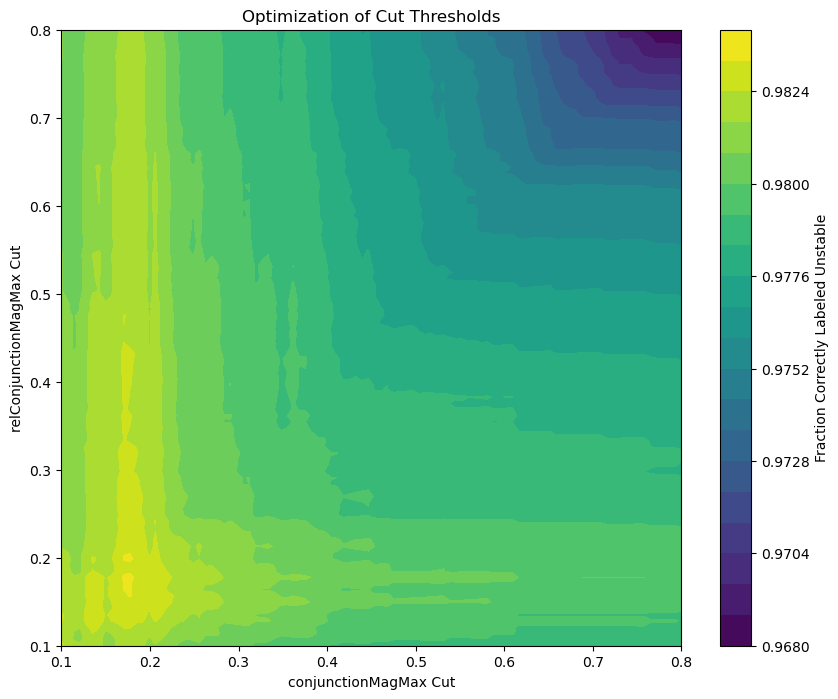

In [22]:
conj_cuts = np.linspace(0.1, 0.8, 100) #resonant
relConj_cuts = np.linspace(0.1, 0.8, 100)

results = []

for c_cut in conj_cuts:
    for rc_cut in relConj_cuts:
        # apply cuts for (what we think) should be nonres and unstable
        nonres = ((data['conjunctionMagMax'] < c_cut) &
                  (data['relConjunctionMagMax'] < rc_cut))
        unstable = (nonres & (data['2BRfillMax'] > 1))
        
        # get subset and count
        unstable_data = data[unstable]

        total = len(unstable_data)
        correct = (unstable_data['Stable'] == False).sum()
        freq = correct / total

        results.append({
            'conj_cut': c_cut,
            'relConj_cut': rc_cut,
            'total': total,
            'correct_unstable': correct,
            'freq': freq
        })

# convert results to a pandas dataframe
results_df = pd.DataFrame(results)

# sort to get best cut pair: highest freq, lowest conj_cut if tie
best = results_df.sort_values(by=['freq', 'conj_cut', 'relConj_cut'], ascending=[False, True, True]).iloc[0]
print("Best cut combo found:")
print(best)

# graph
pivot = results_df.pivot(index='relConj_cut', columns='conj_cut', values='freq')
plt.figure(figsize=(10, 8))
plt.contourf(pivot.columns, pivot.index, pivot.values, levels=20, cmap='viridis')
plt.colorbar(label='Fraction Correctly Labeled Unstable')
plt.xlabel('conjunctionMagMax Cut')
plt.ylabel('relConjunctionMagMax Cut')
plt.title('Optimization of Cut Thresholds')
plt.show()


There are 281 systems (1.8%) that we think should be unstable/not in resonance, but they are stable. Let's analyze these further. 

Isolate the systems that we may be misidentifying.

In [111]:
misclassified_subset3 = data[(data['Stable'] == True) & nonres & unstable]

In [23]:
misclassified_pred_stable = data[(data['Stable'] ==
                                   False) & nonres & pred_stable]

In [24]:
len(misclassified_pred_stable)

15555

In [113]:
misclassified_subset3[misclassified_subset3['hillFacMax'].isnull()]

,EMcrossMax,EMfracstdMax,EPstdMax,MMRstrengthMax,conjunctionMagMax,relConjunctionMagMax,pomega1ThetaMax,pomega2ThetaMax,pMax,qMax,...,threeBRfillfac,massFac,Tsec,2BRfillMax,2BRfillMin,InitialStable,runstring,instability_time,shadow_instability_time,Stable
21384,0.037962,NaN,NaN,NaN,0.037770,0.028122,0.021476,0.037770,55.0,3.0,...,NaN,NaN,15416.446507,4.871442,0.012837,0.0,4122286.bin,1.000000e+09,1.000000e+09,True
27377,0.069003,NaN,NaN,NaN,0.073381,0.089107,0.015784,0.073381,21.0,2.0,...,NaN,NaN,28128.928539,4.121302,0.004312,0.0,4721028.bin,1.000000e+09,1.000000e+09,True
34056,0.069755,NaN,NaN,NaN,0.059385,0.048785,0.034788,0.055225,31.0,3.0,...,NaN,NaN,12020.813364,3.218149,0.008005,0.0,5434143.bin,1.000000e+09,1.000000e+09,True
45450,0.119716,NaN,NaN,NaN,0.243154,0.114841,0.243154,0.085318,19.0,3.0,...,NaN,NaN,3472.413569,3.645944,NaN,0.0,6432336.bin,1.000000e+09,1.000000e+09,True
64468,0.143838,NaN,NaN,NaN,0.060530,0.034986,0.060530,0.035553,11.0,2.0,...,NaN,NaN,18213.493976,1.909486,NaN,0.0,7132905.bin,1.000000e+09,1.000000e+09,True
68627,0.141995,NaN,NaN,NaN,0.034598,0.010552,0.021754,0.021355,11.0,2.0,...,NaN,NaN,27962.746182,3.311152,NaN,0.0,7244808.bin,1.000000e+09,1.000000e+09,True
72126,0.103527,NaN,NaN,NaN,0.097898,0.078744,0.023855,0.097898,29.0,4.0,...,NaN,NaN,4905.821946,3.864329,0.074888,0.0,7522974.bin,1.000000e+09,1.000000e+09,True
74597,0.077428,NaN,NaN,NaN,0.091906,0.034172,0.048182,0.051058,19.0,2.0,...,NaN,NaN,9436.813964,3.655356,0.012971,0.0,7544145.bin,1.000000e+09,1.000000e+09,True
75842,0.097119,NaN,NaN,NaN,0.052320,0.041747,0.040894,0.016267,23.0,3.0,...,NaN,NaN,30395.686567,12.922846,NaN,0.0,7630439.bin,1.000000e+09,1.000000e+09,True
98253,0.100835,NaN,NaN,NaN,0.055141,0.041379,0.035321,0.055141,15.0,2.0,...,NaN,NaN,8146.386741,4.720655,0.759760,0.0,8439772.bin,1.000000e+09,1.000000e+09,True


In [43]:
print(misclassified_subset3[misclassified_subset3['hillFacMax']<1].iloc[0])

EMcrossMax                     0.132689
EMfracstdMax                   0.071013
EPstdMax                       0.001214
MMRstrengthMax                 1.312552
conjunctionMagMax              0.192363
relConjunctionMagMax           0.185831
pomega1ThetaMax                  0.0993
pomega2ThetaMax                0.169754
pMax                               23.0
qMax                                4.0
dRatioMax                      0.056597
hillFacMax                     0.992826
EMcrossMin                     0.666032
EMfracstdMin                   0.031057
EPstdMin                       0.019138
MMRstrengthMin                      NaN
conjunctionMagMin              0.962521
relConjunctionMagMin            0.94413
pomega1ThetaMin                0.844003
pomega2ThetaMin                0.962521
pMin                                2.0
qMin                                1.0
dRatioMin                           NaN
hillFacMin                     3.006746
MEGNO                          1.952926


In [25]:
datapath = '../training_data/dataset/resonant/'
misclassified_pred_stable.to_csv(datapath + 'misclassified_pred_stable.csv')

In [22]:
mis_data = pd.read_csv(datapath + 'possible_misclassified2.csv')

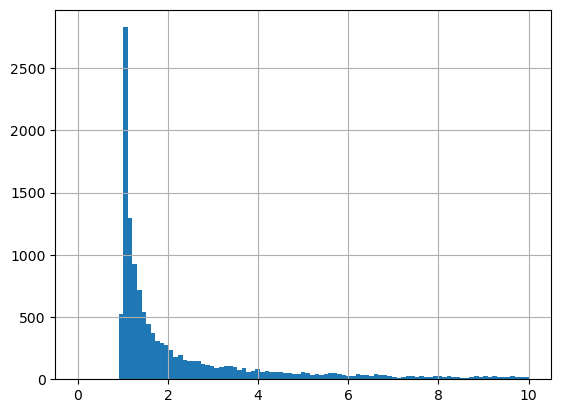

In [51]:
data[pred_unstable]['hillFacMax'].hist(bins=np.linspace(0, 10, 100))
plt.show()

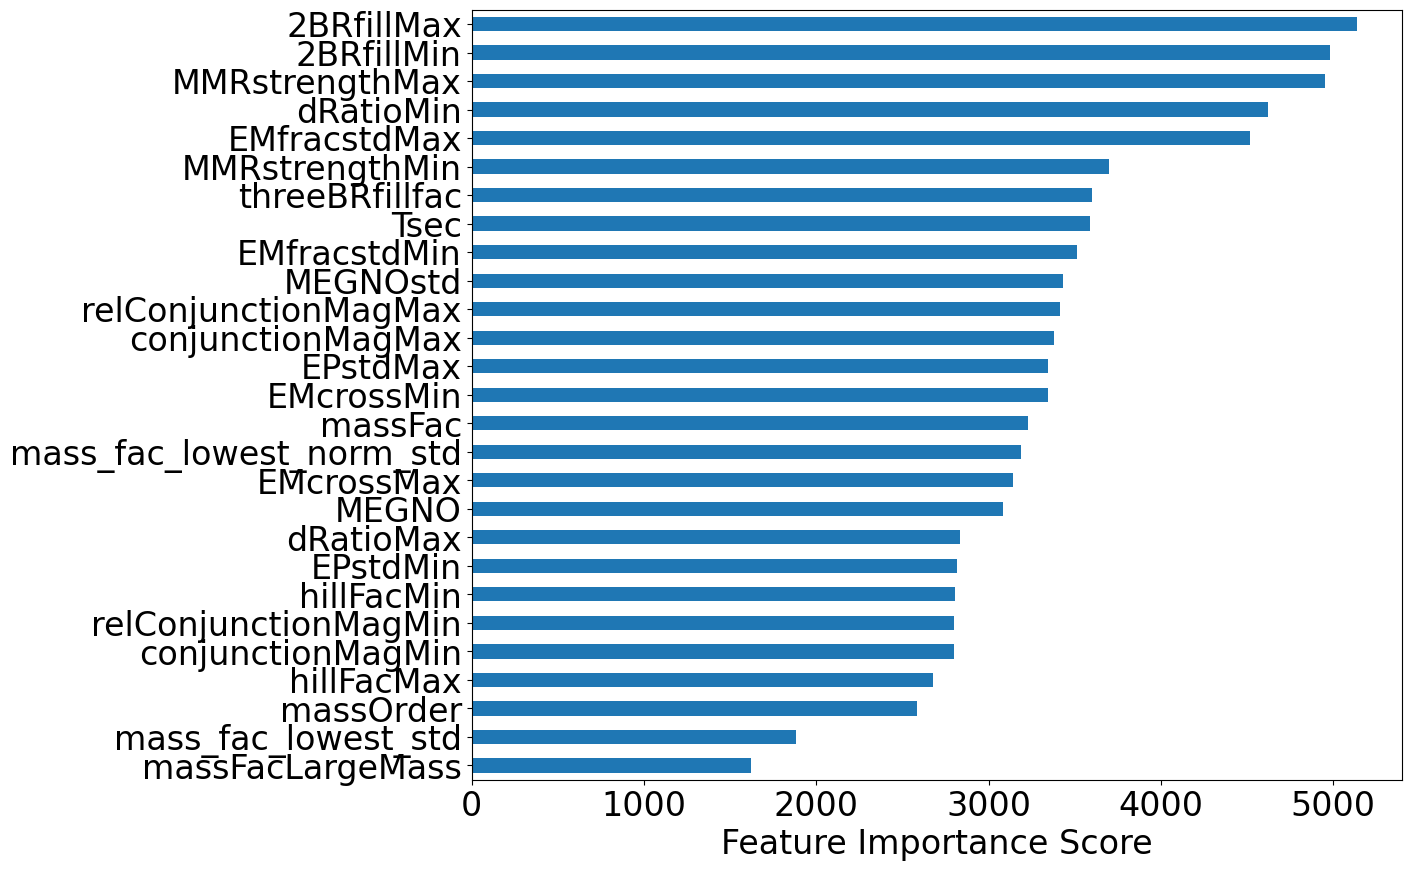

In [35]:
feat_imp = pd.Series(model.get_booster().get_fscore()).sort_values(ascending=False)
ax = feat_imp.plot.barh(figsize=(12,10), fontsize=24)
ax.set_xlabel('Feature Importance Score', fontsize=24)
ax.invert_yaxis()
plt.show()

Testing function

In [105]:
def findAUC(features):
    trainX, trainY, testX, testY = train_test(data, featuresStrengthWidth)

    model = XGBClassifier(learning_rate = 0.05, 
                         max_depth = 15, 
                         subsample = 0.95,
                         min_child_weight = 5,
                         n_estimators = 200,
                         )
    model.fit(trainX,trainY)
    roc_auc, fpr, tpr, ROCthresholds = ROC_curve(model, testX, testY)
    return roc_auc

Test 3BRfill

In [106]:
findAUC(featuresWidth)

0.9604324909063018

In [107]:
findAUC(featuresStrengthWidth)


0.9604324909063018

Seems to not make a large diff at all and might be redundant 

Demonstration of potential ablation study

In [39]:
len(featuresWidth)

20

In [33]:
for i in range(len(featuresWidth)):
    print(i,f'Not {featuresWidth[i]}', findAUC(featuresWidth[:i] + featuresWidth[i+1:]))

0 Not EMcrossMax 0.9595450381098151
1 Not EMfracstdMax 0.9560563060840396
2 Not EPstdMax 0.9589160082969652
3 Not MMRstrengthMax 0.9594167834716806
4 Not conjunctionMagMax 0.9597916743957974
5 Not relConjunctionMagMax 0.9597895287238994
6 Not EMcrossMin 0.959177860006304
7 Not EMfracstdMin 0.9577145480164618
8 Not EPstdMin 0.9585413348395949
9 Not MMRstrengthMin 0.9599205306919301
10 Not conjunctionMagMin 0.9603435180114586
11 Not relConjunctionMagMin 0.9602659331252351
12 Not MEGNO 0.9601337060945332
13 Not MEGNOstd 0.9600808036840258
14 Not massOrder 0.9587619838493825
15 Not Tsec 0.9579680417538472
16 Not 2BRfillMax 0.9579658815841665
17 Not 2BRfillMin 0.9583182067088982
18 Not dRatioMax 0.9594141811196152
19 Not dRatioMin 0.9597245569089673


The reason why sometimes it does better when you remove features is since the complexity of the model is limited, so if the info is already redundant, forcing more features can be less effective (your not actually forcing the features)

This effect can be negated by allowing for more depth and more estimators